In [14]:
import geohexgrid as ghg
import numpy as np
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint, GeometryCollection
import geopandas as gpd
from math import comb

## Get the shape of some city

  id                                     geometry
0  1  POLYGON ((0 0, 0 100, 100 100, 100 0, 0 0))


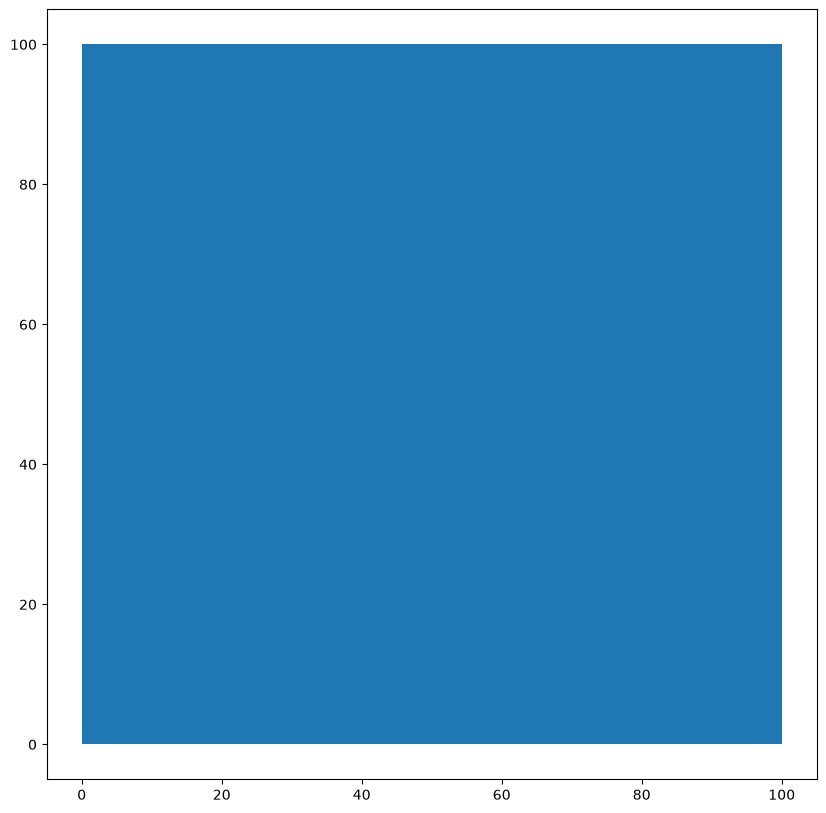

In [2]:
d = {'id': ['1'], 'geometry': [Polygon([(0., 0.), (0., 100.), (100., 100.), (100., 0.)])]}
base = gpd.GeoDataFrame(data=d, crs=None)
background = base.plot(figsize=(10, 10))
print(base)

## Create hex grid

<Axes: >

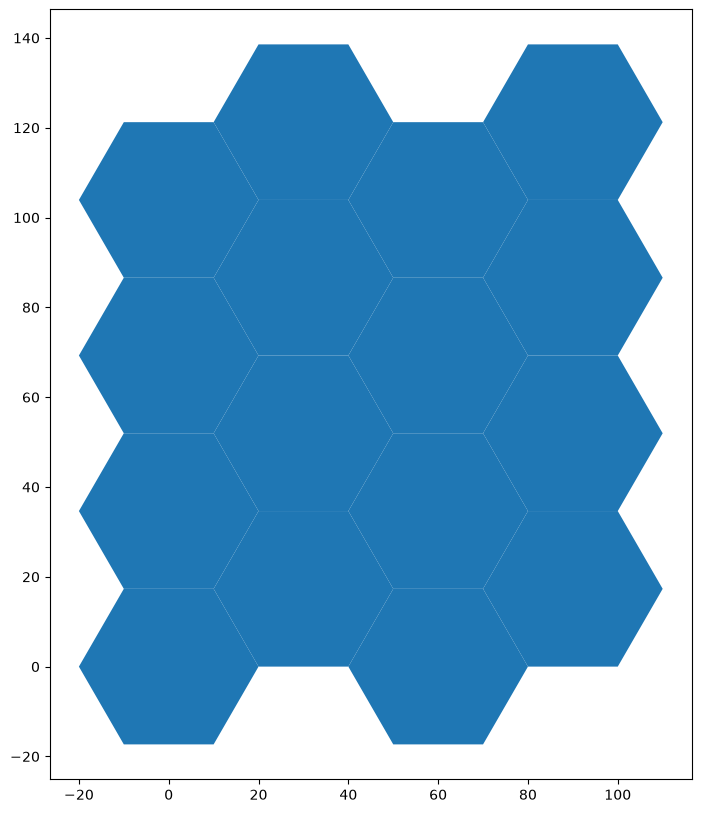

In [3]:
grid = ghg.make_grid_from_bounds(0., 0., 100., 100., R=20.)
grid.plot(figsize=(10, 10))

In [4]:
type(grid)

geopandas.geodataframe.GeoDataFrame

In [5]:
hex_example = grid.iat[0,-1]
hex_example
print(hex_example)

POLYGON ((-10 -17.32050807568877, 10 -17.32050807568877, 20 0, 10 17.32050807568877, -10 17.32050807568877, -20 0, -10 -17.32050807568877))


In [6]:
print(f"area: {hex_example.area}")
print(f"boundary: {hex_example.boundary}")
print(f"bounds: {hex_example.bounds}")
print(f"centroid: {hex_example.centroid}")

area: 1039.2304845413262
boundary: LINESTRING (-10 -17.32050807568877, 10 -17.32050807568877, 20 0, 10 17.32050807568877, -10 17.32050807568877, -20 0, -10 -17.32050807568877)
bounds: (-20.0, -17.32050807568877, 20.0, 17.32050807568877)
centroid: POINT (2.917205616084103e-16 0)


## Extract seed points

In [7]:
grid['centroid'] = grid['geometry'].centroid
grid.head()

,cell_id,geometry,centroid
0,"0,0","POLYGON ((-10 -17.32051, 10 -17.32051, 20 0, 1...",POINT (2.91721e-16 0)
1,"1,1","POLYGON ((20 0, 40 0, 50 17.32051, 40 34.64102...",POINT (30 17.32051)
2,"2,0","POLYGON ((50 -17.32051, 70 -17.32051, 80 0, 70...",POINT (60 0)
3,"3,1","POLYGON ((80 0, 100 0, 110 17.32051, 100 34.64...",POINT (90 17.32051)
4,"0,2","POLYGON ((-10 17.32051, 10 17.32051, 20 34.641...",POINT (2.91721e-16 34.64102)


<Axes: >

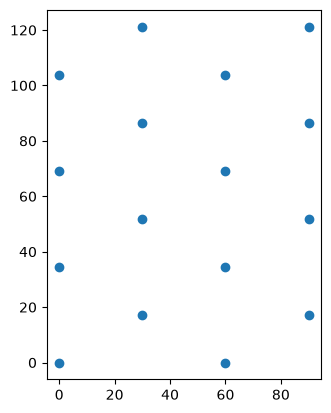

In [8]:
centroids = grid["centroid"]
centroids.plot()

## Create demand matrix

no. of seed points: 16
no. of pairs is actually: 120
no. of pairs should be: 120


<Axes: >

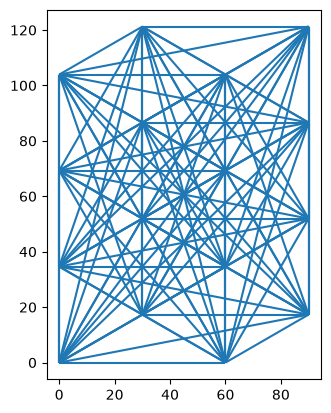

In [15]:
def od_pairs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    seed_points = gdf['cell_id'].values.tolist()
    geo = gdf['centroid'].values.tolist()
    n = len(seed_points)
    ids = []
    pairs = []
    lines = []
    for i in range(n):
        for j in range(i+1, n):
            # print(f'seed_points[i]: {seed_points[i]}, seed_points[j]: {seed_points[j]}')
            # print(f'geo[i]: {geo[i]}, geo[j]: {geo[j]}')
            ids.append((seed_points[i], seed_points[j]))
            lines.append(LineString([geo[i], geo[j]]))
            pairs.append((geo[i], geo[j]))
    return gpd.GeoDataFrame({'pair_id': ids, 'geometry': lines})

test = od_pairs(grid)
print(f'no. of seed points: {grid.shape[0]}')
print(f'no. of pairs is actually: {test.shape[0]}')
print(f'no. of pairs should be: {comb(grid.shape[0], 2)}')
test.head()
test.plot()